# Concrete Beam Section Calculation

## Set-Based Design Analysis

This notebook provides tools for analyzing reinforced concrete beam sections using set-based design methodology.

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 2. Define Material Properties

In [ ]:
# Concrete properties
fc = 30  # Concrete compressive strength (MPa)
fck = 25  # Characteristic compressive strength (MPa)
gamma_c = 1.5  # Safety factor for concrete
fcd = fck / gamma_c  # Design compressive strength (MPa)

# Steel reinforcement properties
fy = 500  # Yield strength of steel (MPa)
fyk = 500  # Characteristic yield strength (MPa)
gamma_s = 1.15  # Safety factor for steel
fyd = fyk / gamma_s  # Design yield strength (MPa)

concrete_cover = [35]                  #Concrete cover in [mm]
Rebar_size_s = [16,20,25]  
Rebar_size_prim = Rebar_size_s
n_rebar_layers = [2]
Stirrups_Size = 12 

# Concrete strain at crushing
epsilon_cu = 0.0035  # Concrete ultimate strain
epsilon_y = fyd / (200000)  # Steel yield strain

print(f"Design concrete strength (fcd): {fcd:.2f} MPa")
print(f"Design steel strength (fyd): {fyd:.2f} MPa")
print(f"Steel yield strain: {epsilon_y:.6f}")

Design concrete strength (fcd): 16.67 MPa
Design steel strength (fyd): 434.78 MPa
Steel yield strain: 0.002174


## 3. Generation of reinforcement layout and concrete rectangular section

In [42]:
# -----------------------------------------
# EC2 minimum spacing ONLY (rounded up to 5 mm)
# -----------------------------------------

max_aggregate_size = 16  # mm

spacing_values = {}

for phi in Rebar_size_s:

    # EC2 minimum clear spacing
    s_min_raw = max(phi, 20, max_aggregate_size + 5)

    # Round UP to nearest 5 mm
    s_min = int(np.ceil(s_min_raw / 5.0) * 5)

    spacing_values[phi] = s_min

print("Minimum EC2 spacing per diameter:")
for k, v in spacing_values.items():
    print(f"Ø{k} → {v} mm")


Minimum EC2 spacing per diameter:
Ø16 → 25 mm
Ø20 → 25 mm
Ø25 → 25 mm


## Rebar layout

In [ ]:
final_combinations = []
comb_id = 1

for n_layers in n_rebar_layers:

    # -------- 1 Layer --------
    if n_layers == 1:
        for si1 in Rebar_size_s:

            sp1 = spacing_values[si1]   # <-- spacing assigned here

            for si_prim in [p for p in Rebar_size_prim if p == si1]:
                for con_c in concrete_cover:
                    for c in concrete_class:

                        comb = {
                            "Combination name": comb_id,
                            "no layers rebar": n_layers,
                            "Spacing layer 1": sp1,
                            "Spacing layer 2": "",
                            "Size layer 1": si1,
                            "Size layer 2": "",
                            "Concrete class": c,
                            "Concrete cover": con_c,
                            "Stirrup size": Stirrups_Size,
                        }

                        final_combinations.append(comb)
                        comb_id += 1

    # -------- 2 Layers --------
    elif n_layers == 2:
        for si1 in Rebar_size_s:
            for si2 in [si1]:

                sp1 = spacing_values[si1]
                sp2 = spacing_values[si2]

                for si_prim in [p for p in Rebar_size_prim if p == si1]:
                    for con_c in concrete_cover:
                        for c in concrete_class:

                            comb = {
                                "Combination name": comb_id,
                                "no layers rebar": n_layers,
                                "Spacing layer 1": sp1,
                                "Spacing layer 2": sp2,
                                "Size layer 1": si1,
                                "Size layer 2": si2,
                                "Concrete class": c,
                                "Concrete cover": con_c,
                                "Stirrup size": Stirrups_Size,
                            }

                            final_combinations.append(comb)
                            comb_id += 1

# ----------------------------
# Display / print results
# ----------------------------
print(f"Number of combinations: {len(final_combinations)}")
#print("spacing =", spacing)
df = pd.DataFrame(final_combinations)
df


Number of combinations: 12


,Combination name,no layers rebar,Spacing layer 1,Spacing layer 2,Size layer 1,Size layer 2,Concrete class,Concrete cover,Stirrup size,Size layer prim
0,1,1,25,,16,,30,25,12,16
1,2,1,25,,16,,30,35,12,16
2,3,1,25,,20,,30,25,12,20
3,4,1,25,,20,,30,35,12,20
4,5,1,25,,25,,30,25,12,25
5,6,1,25,,25,,30,35,12,25
6,7,2,25,25,16,16,30,25,12,16
7,8,2,25,25,16,16,30,35,12,16
8,9,2,25,25,20,20,30,25,12,20
9,10,2,25,25,20,20,30,35,12,20


## 4. Generate concrete sections based on reinforcement layout, chosen section heights and concrete cover 

In [45]:
import numpy as np
import pandas as pd

# -------------------------------------------------
# New parameters for section sizing / reinforcement count
# -------------------------------------------------
section_height  = np.linspace(200, 500, 50)  # [mm]
rebars_layer_1  = [2, 3, 4]
rebars_layer_2  = [2]

# -------------------------------------------------
# Build "concrete_section" by combining:
# - each item in final_combinations
# - each section_height
# - each rebars_layer_1 / rebars_layer_2
# and computing width + effective heights + rebar areas
# -------------------------------------------------
concrete_section = []
sec_id = 1

for comb in final_combinations:
    cover = float(comb["Concrete cover"])

    # Sizes might be '' for 1-layer cases -> handle cleanly
    size1 = float(comb["Size layer 1"]) if comb["Size layer 1"] != "" else np.nan
    size2 = float(comb["Size layer 2"]) if comb["Size layer 2"] != "" else np.nan

    sp1 = float(comb["Spacing layer 1"]) if comb["Spacing layer 1"] != "" else np.nan
    sp2 = float(comb["Spacing layer 2"]) if comb["Spacing layer 2"] != "" else np.nan

    n_layers = int(comb["no layers rebar"])

    for h in section_height:
        for n1 in rebars_layer_1:
            for n2 in rebars_layer_2:

                # ----------------------------
                # Width (based on layer 1, per your formula)
                # width = cover + size1*n1 + sp1*(n1-1) + cover
                # ----------------------------
                width = cover + size1 * n1 + sp1 * (n1 - 1) + cover

                # ----------------------------
                # Rebar areas
                # ----------------------------
                rebar_area_layer_1 = np.pi * (size1 ** 2) / 4.0 * n1

                if n_layers >= 2 and not np.isnan(size2):
                    rebar_area_layer_2 = np.pi * (size2 ** 2) / 4.0 * n2
                else:
                    rebar_area_layer_2 = 0.0

                # ----------------------------
                # Effective height to layer 1 (given)
                # d1 = h - cover - size1/2
                # ----------------------------
                effective_height_layer_1 = h - cover - (size1 / 2.0)

                # Optional: effective height to layer 2 if present
                # Assumption: layer 2 sits above layer 1 by (size1/2 + clear gap + size2/2)
                # If you have a specific vertical clear spacing rule, replace `vertical_clear_gap`.
                vertical_clear_gap = 0.0
                if n_layers >= 2 and not np.isnan(size2):
                    effective_height_layer_2 = h - cover - size1 - vertical_clear_gap - (size2 / 2.0)
                else:
                    effective_height_layer_2 = np.nan

                # Store: original combination + new section info
                row = dict(comb)  # copy everything from final_combinations
                row.update({
                    "Section ID": sec_id,
                    "Section height": float(h),
                    "n rebars layer 1": int(n1),
                    "n rebars layer 2": int(n2) if n_layers >= 2 else 0,
                    "Section width": float(width),
                    "As layer 1": float(rebar_area_layer_1),
                    "As layer 2": float(rebar_area_layer_2),
                    "Effective height layer 1": float(effective_height_layer_1),
                    "Effective height layer 2": float(effective_height_layer_2) if not np.isnan(effective_height_layer_2) else np.nan,
                })

                concrete_section.append(row)
                sec_id += 1

# -------------------------------------------------
# View as DataFrame in Jupyter
# -------------------------------------------------
df_section = pd.DataFrame(concrete_section)
print(f"Number of concrete sections: {len(df_section)}")
df_section


Number of concrete sections: 1800


,Combination name,no layers rebar,Spacing layer 1,Spacing layer 2,Size layer 1,Size layer 2,Concrete class,Concrete cover,Stirrup size,Size layer prim,Section ID,Section height,n rebars layer 1,n rebars layer 2,Section width,As layer 1,As layer 2,Effective height layer 1,Effective height layer 2
0,1,1,25,,16,,30,25,12,16,1,200.000000,2,0,107.0,402.123860,0.000000,167.000000,NaN
1,1,1,25,,16,,30,25,12,16,2,200.000000,3,0,148.0,603.185789,0.000000,167.000000,NaN
2,1,1,25,,16,,30,25,12,16,3,200.000000,4,0,189.0,804.247719,0.000000,167.000000,NaN
3,1,1,25,,16,,30,25,12,16,4,206.122449,2,0,107.0,402.123860,0.000000,173.122449,NaN
4,1,1,25,,16,,30,25,12,16,5,206.122449,3,0,148.0,603.185789,0.000000,173.122449,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,12,2,25,25,25,25,30,35,12,25,1796,493.877551,3,2,195.0,1472.621556,981.747704,446.377551,421.377551
1796,12,2,25,25,25,25,30,35,12,25,1797,493.877551,4,2,245.0,1963.495408,981.747704,446.377551,421.377551
1797,12,2,25,25,25,25,30,35,12,25,1798,500.000000,2,2,145.0,981.747704,981.747704,452.500000,427.500000
1798,12,2,25,25,25,25,30,35,12,25,1799,500.000000,3,2,195.0,1472.621556,981.747704,452.500000,427.500000


## 5. For simplifying we reduce the initial set to include sections with 1 layer of rebars

In [46]:
# ---------------------------------------
# Keep only sections with 1 rebar layer
# ---------------------------------------
df_section_1_layer = df_section[df_section["no layers rebar"] == 1].copy()



df_section_1_layer = df_section_1_layer.drop(
    columns=[
        "Size layer 2",
        "Spacing layer 2",
        "As layer 2",
        "Effective height layer 2",
        "n rebars layer 2"
    ],
    errors="ignore"
)

print(f"Number of 1-layer concrete sections: {len(df_section_1_layer)}")
df_section_1_layer


Number of 1-layer concrete sections: 900


,Combination name,no layers rebar,Spacing layer 1,Size layer 1,Concrete class,Concrete cover,Stirrup size,Size layer prim,Section ID,Section height,n rebars layer 1,Section width,As layer 1,Effective height layer 1
0,1,1,25,16,30,25,12,16,1,200.000000,2,107.0,402.123860,167.000000
1,1,1,25,16,30,25,12,16,2,200.000000,3,148.0,603.185789,167.000000
2,1,1,25,16,30,25,12,16,3,200.000000,4,189.0,804.247719,167.000000
3,1,1,25,16,30,25,12,16,4,206.122449,2,107.0,402.123860,173.122449
4,1,1,25,16,30,25,12,16,5,206.122449,3,148.0,603.185789,173.122449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,6,1,25,25,30,35,12,25,896,493.877551,3,195.0,1472.621556,446.377551
896,6,1,25,25,30,35,12,25,897,493.877551,4,245.0,1963.495408,446.377551
897,6,1,25,25,30,35,12,25,898,500.000000,2,145.0,981.747704,452.500000
898,6,1,25,25,30,35,12,25,899,500.000000,3,195.0,1472.621556,452.500000


## 4. Flexural Capacity Analysis

In [47]:
import numpy as np
import pandas as pd

# =========================================================
# Flexural capacity functions (singly reinforced)
# Units: mm, N, MPa (= N/mm2), kNm
# =========================================================
def calculate_neutral_axis(b, d, As, fcd, fyd):
    """
    Neutral axis depth x from equilibrium:
    0.8*x*b*fcd = As*fyd
    """
    if b <= 0 or d <= 0 or As <= 0 or fcd <= 0 or fyd <= 0:
        return np.nan
    return (As * fyd) / (0.8 * b * fcd)

def calculate_moment_capacity(d, As, fyd, x):
    """
    Moment capacity with lever arm z = d - 0.4x
    M = As*fyd*z  [Nmm] -> [kNm]
    """
    if np.isnan(x):
        return np.nan, np.nan
    z = d - 0.4 * x
    M_kNm = (As * fyd * z) / 1e6  # Nmm -> kNm
    return M_kNm, z

def check_section(d, fyd, x, epsilon_cu=0.0035, Es=200000):
    """
    Classify section type using an ultimate NA depth estimate:
    x_u = (eps_cu / (eps_cu + eps_su)) * d, eps_su ~ fyd/Es
    """
    if np.isnan(x):
        return np.nan, np.nan, "Invalid"
    x_u = (epsilon_cu / (epsilon_cu + fyd / Es)) * d
    section_type = "Tension controlled" if x < 0.6 * x_u else "Compression controlled"
    return x, x_u, section_type

# =========================================================
# Build sectional_capacity from df_section_1_layer or df_section
# =========================================================
# Choose your source:
# - if you already filtered to 1-layer: df_section_1_layer
# - otherwise use df_section and filter here
source_df = df_section.copy()
source_df = source_df[source_df["no layers rebar"] == 1].copy()

# --- Material parameters ---
# Use the same fcd you used earlier (MPa = N/mm2)
# Define fyd (MPa). Example: B500 -> fyk=500, gamma_s=1.15 => fyd ~ 435
fyd = 435.0  # N/mm2

rows = []

for _, r in source_df.iterrows():
    b = float(r["Section width"])                    # mm
    h = float(r["Section height"])                   # mm
    d = float(r["Effective height layer 1"])         # mm (already computed in your section builder)
    As = float(r["As layer 1"])                      # mm2
    fcd_i = float(r["Concrete class"])               # MPa (N/mm2)

    # Neutral axis
    x = calculate_neutral_axis(b, d, As, fcd_i, fyd)

    # Section type
    x, x_u, section_type = check_section(d, fyd, x)

    # Moment capacity
    M_kNm, z = calculate_moment_capacity(d, As, fyd, x)

    out = dict(r)  # keep all original columns
    out.update({
        "b [mm]": b,
        "h [mm]": h,
        "d [mm]": d,
        "As [mm2]": As,
        "fcd [MPa]": fcd_i,
        "fyd [MPa]": fyd,
        "x [mm]": x,
        "x_u [mm]": x_u,
        "z [mm]": z,
        "Section type": section_type,
        "M_Rd [kNm]": M_kNm,
    })
    rows.append(out)

sectional_capacity = pd.DataFrame(rows)

print(f"Number of rows in sectional_capacity: {len(sectional_capacity)}")
sectional_capacity


Number of rows in sectional_capacity: 900


,Combination name,no layers rebar,Spacing layer 1,Spacing layer 2,Size layer 1,Size layer 2,Concrete class,Concrete cover,Stirrup size,Size layer prim,...,h [mm],d [mm],As [mm2],fcd [MPa],fyd [MPa],x [mm],x_u [mm],z [mm],Section type,M_Rd [kNm]
0,1,1,25,,16,,30,25,12,16,...,200.000000,167.000000,402.123860,30.0,435.0,68.116775,102.995595,139.753290,Compression controlled,24.446188
1,1,1,25,,16,,30,25,12,16,...,200.000000,167.000000,603.185789,30.0,435.0,73.869881,102.995595,137.452047,Compression controlled,36.065468
2,1,1,25,,16,,30,25,12,16,...,200.000000,167.000000,804.247719,30.0,435.0,77.126931,102.995595,136.149228,Compression controlled,47.631502
3,1,1,25,,16,,30,25,12,16,...,206.122449,173.122449,402.123860,30.0,435.0,68.116775,106.771554,145.875739,Compression controlled,25.517150
4,1,1,25,,16,,30,25,12,16,...,206.122449,173.122449,603.185789,30.0,435.0,73.869881,106.771554,143.574496,Compression controlled,37.671912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,6,1,25,,25,,30,35,12,25,...,493.877551,446.377551,1472.621556,30.0,435.0,136.878286,275.298930,391.626237,Tension controlled,250.871999
896,6,1,25,,25,,30,35,12,25,...,493.877551,446.377551,1963.495408,30.0,435.0,145.258589,275.298930,388.274115,Tension controlled,331.632883
897,6,1,25,,25,,30,35,12,25,...,500.000000,452.500000,981.747704,30.0,435.0,122.718463,279.074890,403.412615,Tension controlled,172.281493
898,6,1,25,,25,,30,35,12,25,...,500.000000,452.500000,1472.621556,30.0,435.0,136.878286,279.074890,397.748686,Tension controlled,254.793981


## Shear capacity

In [48]:
import numpy as np
import pandas as pd

# =========================
# EC2 shear helpers
# =========================
def shear_VRdc_EC2(bw, d, Asl, fck, gamma_c=1.5, k1=0.15, sigma_cp=0.0):
    """
    EC2-type concrete shear resistance (no axial load by default):
    V_Rd,c = [ C_Rd,c * k * (100*rho_l*fck)^(1/3) + k1*sigma_cp ] * bw * d

    Units: bw,d [mm], Asl [mm2], fck [MPa] -> V_Rd,c [kN]
    """
    if bw <= 0 or d <= 0 or Asl <= 0 or fck <= 0:
        return np.nan, {}

    C_Rdc = 0.18 / gamma_c
    k = min(2.0, 1.0 + np.sqrt(200.0 / d))
    rho_l = min(0.02, Asl / (bw * d))

    vrdc_N = (C_Rdc * k * (100.0 * rho_l * fck) ** (1.0 / 3.0) + k1 * sigma_cp) * bw * d
    return vrdc_N / 1000.0, {"C_Rd,c": C_Rdc, "k": k, "rho_l": rho_l}

def shear_VRds_EC2(z, Asw, s, fyd, cot_theta=1.0):
    """
    Shear resistance from vertical stirrups:
    V_Rd,s = (Asw/s) * z * fyd * cot(theta)

    Units: z[mm], Asw[mm2], s[mm], fyd[MPa] -> V_Rd,s [kN]
    """
    if z <= 0 or Asw <= 0 or s <= 0 or fyd <= 0:
        return np.nan
    v_N = (Asw / s) * z * fyd * cot_theta
    return v_N / 1000.0

def s_min_stirrups_EC2(bw, d, fck, phi_sw, n_legs=2, fyk=500.0, s_cap_075d=True):
    """
    Compute stirrup spacing 's' using EC2 minimum shear reinforcement:
      rho_w,min = 0.08*sqrt(fck)/fyk
      Asw/s >= rho_w,min * bw  (alpha=90deg => sin(alpha)=1)

    For given Asw (phi_sw & n_legs), the maximum spacing from minimum reinforcement:
      s_rho = Asw / (rho_w,min * bw)

    Then apply detailing caps:
      s <= 0.75 d  (typical) and s <= 600 mm

    Returns chosen s (mm), rho_w,min, Asw (mm2), and governing cap info.
    """
    if bw <= 0 or d <= 0 or fck <= 0 or phi_sw <= 0:
        return np.nan, np.nan, np.nan, "invalid"

    rho_w_min = 0.08 * np.sqrt(fck) / fyk  # dimensionless
    Asw = n_legs * (np.pi * phi_sw**2 / 4.0)  # mm2

    # spacing from minimum reinforcement ratio
    s_rho = Asw / (rho_w_min * bw)  # mm

    # detailing caps (typical)
    s_caps = []
    cap_names = []

    if s_cap_075d:
        s_caps.append(0.75 * d)
        cap_names.append("0.75d")

    s_caps.append(600.0)
    cap_names.append("600mm")

    s_detail = min(s_caps)
    s = min(s_rho, s_detail)

    # identify governing
    if s == s_rho:
        gov = "rho_w,min"
    else:
        # which cap governed?
        gov = cap_names[int(np.argmin(s_caps))]

    return s, rho_w_min, Asw, gov

# =========================
# Build sectional_shear_capacity (1 layer only)
# =========================
# Use your 1-layer sections dataframe if you already made it:
# source_df = df_section_1_layer.copy()
source_df = df_section.copy()
source_df = source_df[source_df["no layers rebar"] == 1].copy()

# ---- Material parameters ----
gamma_c = 1.5
alpha_cc = 1.0

# Steel
fyk = 500.0                 # MPa
gamma_s = 1.15
fyd = fyk / gamma_s         # MPa

# Truss angle choice (cotθ)
cot_theta = 1.0             # conservative typical choice (can be 1.0–2.5 depending on design)

# Stirrups
n_legs = 2                  # typical closed stirrup in a rectangular beam

rows = []

for _, r in source_df.iterrows():
    bw = float(r["Section width"])                 # mm (your computed width)
    d  = float(r["Effective height layer 1"])      # mm
    Asl = float(r["As layer 1"])                   # mm2

    fcd_i = float(r["Concrete class"])             # MPa (YOU confirmed: this is fcd)
    # Convert fcd -> fck estimate: fck = fcd * gamma_c / alpha_cc
    fck = fcd_i * gamma_c / alpha_cc

    # Concrete contribution
    VRdc_kN, info = shear_VRdc_EC2(bw, d, Asl, fck, gamma_c=gamma_c)

    # Minimum stirrups spacing based on EC2 min shear reinforcement
    phi_sw = float(r["Stirrup size"])              # mm
    s_st, rho_w_min, Asw, governing = s_min_stirrups_EC2(
        bw=bw, d=d, fck=fck, phi_sw=phi_sw, n_legs=n_legs, fyk=fyk, s_cap_075d=True
    )

    # Shear contribution from stirrups at minimum requirement spacing
    z = 0.9 * d
    VRds_kN = shear_VRds_EC2(z=z, Asw=Asw, s=s_st, fyd=fyd, cot_theta=cot_theta)

    # Total
    VRd_total_kN = VRdc_kN + VRds_kN

    out = dict(r)
    out.update({
        "fcd [MPa]": fcd_i,
        "fck est [MPa]": fck,
        "b_w [mm]": bw,
        "d [mm]": d,
        "z=0.9d [mm]": z,
        "As_l [mm2]": Asl,
        "k (EC2)": info.get("k", np.nan),
        "rho_l (EC2)": info.get("rho_l", np.nan),

        "phi_sw [mm]": phi_sw,
        "n_legs": n_legs,
        "rho_w,min [-]": rho_w_min,
        "Asw [mm2]": Asw,
        "s_st,min [mm]": s_st,
        "s governing": governing,

        "V_Rd,c [kN]": VRdc_kN,
        "V_Rd,s,min [kN]": VRds_kN,
        "V_Rd,total [kN]": VRd_total_kN,
        "cot(theta)": cot_theta,
        "fyd [MPa]": fyd
    })
    rows.append(out)

sectional_shear_capacity = pd.DataFrame(rows)

print(f"Rows in sectional_shear_capacity: {len(sectional_shear_capacity)}")
sectional_shear_capacity


Rows in sectional_shear_capacity: 900


,Combination name,no layers rebar,Spacing layer 1,Spacing layer 2,Size layer 1,Size layer 2,Concrete class,Concrete cover,Stirrup size,Size layer prim,...,n_legs,"rho_w,min [-]",Asw [mm2],"s_st,min [mm]",s governing,"V_Rd,c [kN]","V_Rd,s,min [kN]","V_Rd,total [kN]",cot(theta),fyd [MPa]
0,1,1,25,,16,,30,25,12,16,...,2,0.001073,226.194671,125.250000,0.75d,19.218773,118.014611,137.233384,1.0,434.782609
1,1,1,25,,16,,30,25,12,16,...,2,0.001073,226.194671,125.250000,0.75d,26.582976,118.014611,144.597587,1.0,434.782609
2,1,1,25,,16,,30,25,12,16,...,2,0.001073,226.194671,125.250000,0.75d,33.947179,118.014611,151.961790,1.0,434.782609
3,1,1,25,,16,,30,25,12,16,...,2,0.001073,226.194671,129.841837,0.75d,19.923360,118.014611,137.937971,1.0,434.782609
4,1,1,25,,16,,30,25,12,16,...,2,0.001073,226.194671,129.841837,0.75d,27.557544,118.014611,145.572155,1.0,434.782609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,6,1,25,,25,,30,35,12,25,...,2,0.001073,226.194671,334.783163,0.75d,73.902434,118.014611,191.917045,1.0,434.782609
896,6,1,25,,25,,30,35,12,25,...,2,0.001073,226.194671,334.783163,0.75d,94.709302,118.014611,212.723913,1.0,434.782609
897,6,1,25,,25,,30,35,12,25,...,2,0.001073,226.194671,339.375000,0.75d,53.326659,118.014611,171.341270,1.0,434.782609
898,6,1,25,,25,,30,35,12,25,...,2,0.001073,226.194671,339.375000,0.75d,74.373668,118.014611,192.388279,1.0,434.782609


## Calculate cost per section (1m) and corresponding CO2 emissions

In [51]:
import numpy as np
import pandas as pd

# =========================================================
# COST + CO2 (per 1 m beam length) and add to both dataframes
# =========================================================
# Assumptions / unit costs (EDIT THESE)
# ---------------------------------------------------------
L = 1.0  # m (per-meter results)

# Concrete
concrete_cost_SEK_per_m3 = 1500.0     # SEK/m3  <-- edit
concrete_co2_kg_per_m3   = 300.0      # kgCO2e/m3 <-- edit

# Reinforcement steel (rebar + stirrups)
steel_cost_SEK_per_kg = 15.0          # SEK/kg  <-- edit
steel_co2_kg_per_kg   = 1.7           # kgCO2e/kg <-- edit

steel_density_kg_per_m3 = 7850.0
mm2_to_m2 = 1e-6
mm_to_m = 1e-3

# Stirrups geometry assumptions (EDIT IF NEEDED)
# We'll approximate each stirrup as a rectangular loop around the section:
# stirrup_length ≈ 2*(b-2cover) + 2*(h-2cover) + hooks
hook_allowance_mm = 200.0  # mm total (approx) <-- edit
n_legs_default = 2         # already used in shear block, but cost uses loop length

def _to_float(x):
    if x == "" or x is None:
        return np.nan
    return float(x)

def section_concrete_volume_m3_per_m(b_mm, h_mm, L_m=1.0):
    # volume = b*h*L
    return (b_mm * mm_to_m) * (h_mm * mm_to_m) * L_m

def steel_mass_kg_from_area(As_mm2, L_m=1.0):
    # mass = area * length * density
    return (As_mm2 * mm2_to_m2) * L_m * steel_density_kg_per_m3

def stirrup_mass_kg_per_m(b_mm, h_mm, cover_mm, phi_sw_mm, s_mm, L_m=1.0, hook_mm=200.0):
    """
    Approx stirrup mass per meter:
      n_stirrups = L / s
      stirrup_length ≈ 2*(b-2c) + 2*(h-2c) + hooks
      mass = n * length * area * density
    """
    if np.isnan(s_mm) or s_mm <= 0:
        return 0.0

    n = (L_m * 1000.0) / s_mm  # number per meter (mm/mm)
    inner_b = max(0.0, b_mm - 2.0 * cover_mm)
    inner_h = max(0.0, h_mm - 2.0 * cover_mm)
    stirrup_len_mm = 2.0 * inner_b + 2.0 * inner_h + hook_mm
    stirrup_len_m = stirrup_len_mm * mm_to_m

    area_m2 = (np.pi * (phi_sw_mm * mm_to_m) ** 2) / 4.0
    mass = n * stirrup_len_m * area_m2 * steel_density_kg_per_m3
    return mass

def add_cost_co2(df, has_shear_min_spacing=False):
    """
    Adds per-meter concrete + steel costs and CO2 to a dataframe.
    Expects columns:
      Section width, Section height, Concrete cover, As layer 1
    If has_shear_min_spacing=True, also expects:
      s_st,min [mm], phi_sw [mm] (or Stirrup size)
    """
    out = df.copy()

    # Concrete volume per m
    b = out["Section width"].astype(float)
    h = out["Section height"].astype(float)
    Vc = (b * mm_to_m) * (h * mm_to_m) * L  # m3/m

    out["Concrete vol [m3/m]"] = Vc
    out["Concrete cost [SEK/m]"] = Vc * concrete_cost_SEK_per_m3
    out["Concrete CO2 [kg/m]"] = Vc * concrete_co2_kg_per_m3

    # Longitudinal steel mass per m (1-layer sections)
    As1 = out["As layer 1"].astype(float)
    m_long = (As1 * mm2_to_m2) * L * steel_density_kg_per_m3
    out["Long steel mass [kg/m]"] = m_long
    out["Long steel cost [SEK/m]"] = m_long * steel_cost_SEK_per_kg
    out["Long steel CO2 [kg/m]"] = m_long * steel_co2_kg_per_kg

    # Stirrups (if shear df includes min spacing)
    if has_shear_min_spacing:
        cover = out["Concrete cover"].astype(float)

        # stirrup diameter column name could be either "phi_sw [mm]" or "Stirrup size"
        if "phi_sw [mm]" in out.columns:
            phi_sw = out["phi_sw [mm]"].astype(float)
        else:
            phi_sw = out["Stirrup size"].astype(float)

        s_st = out["s_st,min [mm]"].astype(float)

        m_st = []
        for bi, hi, ci, phi_i, si in zip(b, h, cover, phi_sw, s_st):
            m_st.append(stirrup_mass_kg_per_m(bi, hi, ci, phi_i, si, L_m=L, hook_mm=hook_allowance_mm))
        m_st = np.array(m_st, dtype=float)

        out["Stirrups mass [kg/m]"] = m_st
        out["Stirrups cost [SEK/m]"] = m_st * steel_cost_SEK_per_kg
        out["Stirrups CO2 [kg/m]"] = m_st * steel_co2_kg_per_kg
    else:
        out["Stirrups mass [kg/m]"] = 0.0
        out["Stirrups cost [SEK/m]"] = 0.0
        out["Stirrups CO2 [kg/m]"] = 0.0

    # Totals
    out["Total steel mass [kg/m]"] = out["Long steel mass [kg/m]"] + out["Stirrups mass [kg/m]"]
    out["Total cost [SEK/m]"] = out["Concrete cost [SEK/m]"] + out["Long steel cost [SEK/m]"] + out["Stirrups cost [SEK/m]"]
    out["Total CO2 [kg/m]"] = out["Concrete CO2 [kg/m]"] + out["Long steel CO2 [kg/m]"] + out["Stirrups CO2 [kg/m]"]

    return out

# ---------------------------------------------------------
# Apply to your two capacity dataframes
#   - sectional_capacity: flexural results (may not have stirrup spacing)
#   - sectional_shear_capacity: has minimum stirrup spacing (s_st,min [mm])
# ---------------------------------------------------------

# Add costs to flexural capacity df
sectional_capacity = add_cost_co2(sectional_capacity, has_shear_min_spacing=False)

# Add costs to shear capacity df (includes minimum stirrup spacing)
sectional_shear_capacity = add_cost_co2(sectional_shear_capacity, has_shear_min_spacing=True)

# Show results
print(f"Rows in sectional_shear_capacity: {len(sectional_shear_capacity)}")
sectional_shear_capacity
print(f"Number of rows in sectional_capacity: {len(sectional_capacity)}")
sectional_capacity

Rows in sectional_shear_capacity: 900
Number of rows in sectional_capacity: 900


,Combination name,no layers rebar,Spacing layer 1,Spacing layer 2,Size layer 1,Size layer 2,Concrete class,Concrete cover,Stirrup size,Size layer prim,...,Concrete CO2 [kg/m],Long steel mass [kg/m],Long steel cost [SEK/m],Long steel CO2 [kg/m],Stirrups mass [kg/m],Stirrups cost [SEK/m],Stirrups CO2 [kg/m],Total steel mass [kg/m],Total cost [SEK/m],Total CO2 [kg/m]
0,1,1,25,,16,,30,25,12,16,...,6.420000,3.156672,47.350084,5.366343,0.0,0.0,0.0,3.156672,79.450084,11.786343
1,1,1,25,,16,,30,25,12,16,...,8.880000,4.735008,71.025127,8.049514,0.0,0.0,0.0,4.735008,115.425127,16.929514
2,1,1,25,,16,,30,25,12,16,...,11.340000,6.313345,94.700169,10.732686,0.0,0.0,0.0,6.313345,151.400169,22.072686
3,1,1,25,,16,,30,25,12,16,...,6.616531,3.156672,47.350084,5.366343,0.0,0.0,0.0,3.156672,80.432738,11.982874
4,1,1,25,,16,,30,25,12,16,...,9.151837,4.735008,71.025127,8.049514,0.0,0.0,0.0,4.735008,116.784310,17.201351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,6,1,25,,25,,30,35,12,25,...,28.891837,11.560079,173.401188,19.652135,0.0,0.0,0.0,11.560079,317.860372,48.543971
896,6,1,25,,25,,30,35,12,25,...,36.300000,15.413439,231.201584,26.202846,0.0,0.0,0.0,15.413439,412.701584,62.502846
897,6,1,25,,25,,30,35,12,25,...,21.750000,7.706719,115.600792,13.101423,0.0,0.0,0.0,7.706719,224.350792,34.851423
898,6,1,25,,25,,30,35,12,25,...,29.250000,11.560079,173.401188,19.652135,0.0,0.0,0.0,11.560079,319.651188,48.902135


## 5. Visualization

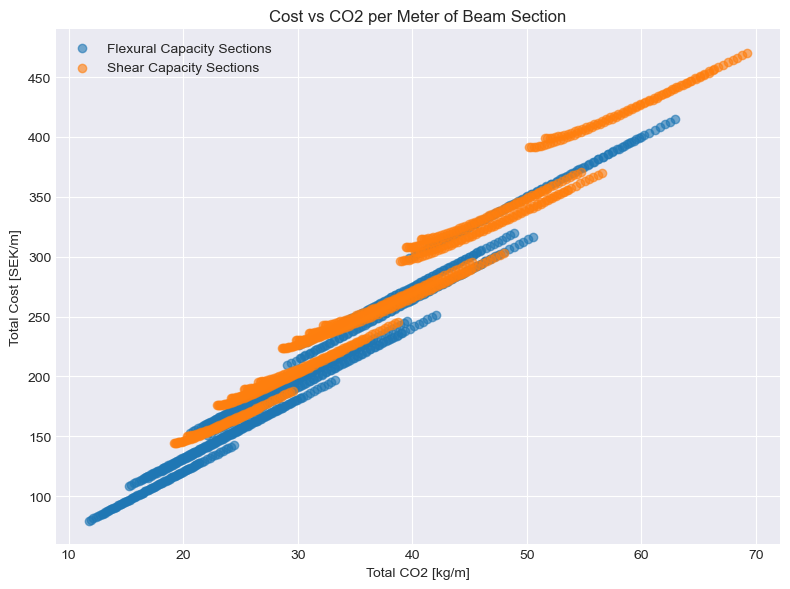

In [52]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(8, 6))

# Flexural capacity points
plt.scatter(
    sectional_capacity["Total CO2 [kg/m]"],
    sectional_capacity["Total cost [SEK/m]"],
    alpha=0.6,
    label="Flexural Capacity Sections"
)

# Shear capacity points
plt.scatter(
    sectional_shear_capacity["Total CO2 [kg/m]"],
    sectional_shear_capacity["Total cost [SEK/m]"],
    alpha=0.6,
    label="Shear Capacity Sections"
)

# Labels and styling
plt.xlabel("Total CO2 [kg/m]")
plt.ylabel("Total Cost [SEK/m]")
plt.title("Cost vs CO2 per Meter of Beam Section")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


## 6. Parametric Analysis

## 7. Summary & Recommendations